# Phần 1 – Tiền Xử Lý Ảnh
**Tập dữ liệu:** [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

---
## Mục lục
1. [Cài đặt & Import thư viện](#1)
2. [Tải và khám phá tập dữ liệu](#2)
3. [Phần 2.1.2 – Phân tích thống kê mô tả](#3)
   - 3a. Phân phối giá trị pixel (Histogram, KDE)
   - 3b. Phân tích class imbalance
   - 3c. Phát hiện ảnh trùng lặp (pHash)
   - 3d. Độ tương phản & độ sáng theo lớp
4. [Phần 2.1.3 – Kỹ thuật tiền xử lý & Ablation Study](#4)
   - 4a. Resize + SSIM/PSNR
   - 4b. Chuyển đổi không gian màu + PCA Explained Variance
   - 4c. Chuẩn hóa + KS Test
   - 4d. Data Augmentation + t-SNE
   - 4e. [Nâng cao] PCA – Scree Plot & Visualization
   - 4f. [Nâng cao] Edge Detection + ANOVA
5. [Tổng hợp kết quả Ablation Study](#5)

---
<a id='1'></a>
## 1. Cài đặt & Import thư viện

In [ ]:
%pip install imagehash scikit-image scikit-learn opencv-python seaborn scipy statsmodels tqdm

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import cv2
from PIL import Image

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage import filters, feature

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from scipy import stats
import scipy.fftpack
from scipy.stats import kstest, ks_2samp, f_oneway

from concurrent.futures import ThreadPoolExecutor , as_completed
import multiprocessing, logging
from pathlib import Path
from collections import defaultdict

# Seed để tái hiện kết quả
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Import thư viện thành công!')

Import thư viện thành công!


---
<a id='2'></a>
## 2. Tải và khám phá tập dữ liệu

**Intel Image Classification** gồm ~25.000 ảnh cảnh quan thiên nhiên và đô thị, chia 6 lớp:
`buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`.

Các lớp phát hiện: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Tổng số ảnh: 14034


,path,label
0,./seg_train/seg_train\buildings\0.jpg,buildings
1,./seg_train/seg_train\buildings\10006.jpg,buildings
2,./seg_train/seg_train\buildings\1001.jpg,buildings
3,./seg_train/seg_train\buildings\10014.jpg,buildings
4,./seg_train/seg_train\buildings\10018.jpg,buildings


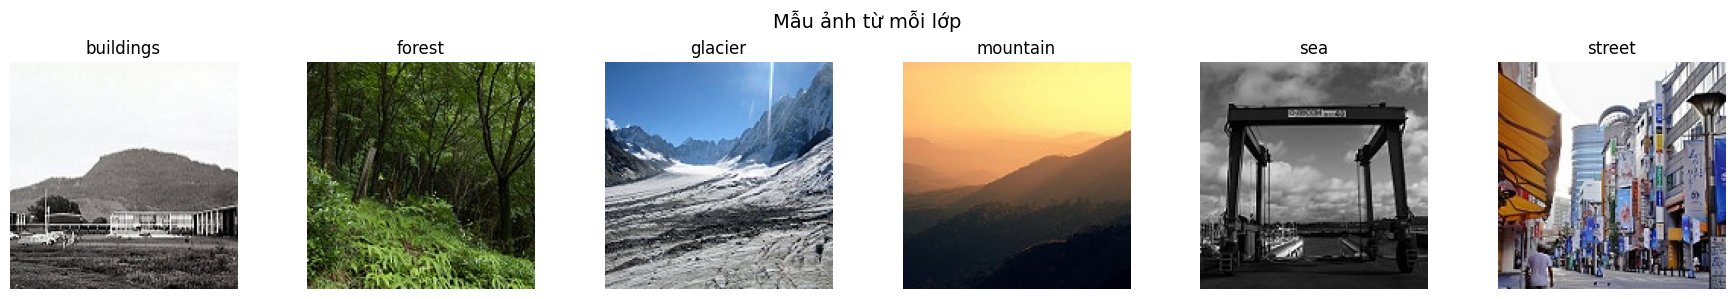

In [2]:
DATA_ROOT = './seg_train/seg_train'
CLASSES = sorted(os.listdir(DATA_ROOT))
print('Các lớp phát hiện:', CLASSES)

# Hàm tiện ích: load danh sách path ảnh
def get_image_paths(root, classes):
    data = []
    for cls in classes:
        paths = glob.glob(os.path.join(root, cls, '*.jpg')) + \
                glob.glob(os.path.join(root, cls, '*.png'))
        for p in paths:
            data.append({'path': p, 'label': cls})
    return pd.DataFrame(data)

df = get_image_paths(DATA_ROOT, CLASSES)
print(f'Tổng số ảnh: {len(df)}')
display(df.head())

# Hàm tiện ích: load ảnh về numpy
def load_image_rgb(path, size=None):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if size:
        img = cv2.resize(img, (size, size))
    return img

# Hiển thị mẫu ảnh từ mỗi lớp
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 3))
for ax, cls in zip(axes, CLASSES):
    sample = df[df['label'] == cls].iloc[0]['path']
    img = load_image_rgb(sample)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Mẫu ảnh từ mỗi lớp', fontsize=14)
plt.tight_layout()
plt.show()

---
<a id='3'></a>
## 3. Phần 2.1.2 – Phân tích thống kê mô tả toàn diện

---
### 3a. Phân phối giá trị pixel (Histogram & KDE)

**Lý thuyết:**

Histogram pixel cho thấy phân bố cường độ sáng của ảnh trên thang [0, 255]. Với ảnh màu RGB, mỗi kênh (R, G, B) có phân bố riêng biệt. KDE (Kernel Density Estimation) làm mịn histogram để quan sát xu hướng tổng quát hơn.

$$f(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

trong đó $K$ là hàm kernel (thường là Gaussian), $h$ là bandwidth.

In [ ]:
# Sample N ảnh để tính histogram
N_SAMPLE = 500

sample_df = (
    df.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(min(len(x), N_SAMPLE // len(CLASSES)), random_state=SEED))
      .reset_index(drop=True)
)

# Load tất cả ảnh mẫu
images_by_class = {}
for cls in CLASSES:
    paths = sample_df[sample_df['label'] == cls]['path'].tolist()
    images_by_class[cls] = [load_image_rgb(p) for p in paths]

# np.stack → (N, H, W, 3) → reshape → (N*H*W, 3)
def get_all_pixels(images: list[np.ndarray]) -> np.ndarray:
    """Stack nhiều ảnh → ma trận (N_pixels, 3)."""
    return np.stack(images_by_class[cls]).reshape(-1, 3)

pixels_by_class = {cls: get_all_pixels(imgs) for cls, imgs in images_by_class.items()}

CHANNELS = [('Red', 'red'), ('Green', 'green'), ('Blue', 'blue')]

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(15, 3 * len(CLASSES)))

for i, cls in enumerate(CLASSES):
    all_pixels = pixels_by_class[cls]          
    
    for j, (ch_name, col) in enumerate(CHANNELS):
        ax = axes[i, j] 
        channel_data = all_pixels[:, j]
        
        ax.hist(channel_data, bins=50, color=col, alpha=0.5, density=True, label='Histogram')
        sns.kdeplot(channel_data, ax=ax, color=col, linewidth=2, label='KDE')
        
        ax.set_title(f'{cls} – {ch_name}', fontweight='bold')
        ax.set_xlabel('Pixel value (0–255)')
        ax.set_xlim(0, 255)                 
        ax.legend(fontsize=8)

plt.suptitle('Phân phối giá trị pixel theo lớp và kênh màu', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**📝 Phân tích kết quả:**

> TODO: Nhận xét phân bố pixel của từng lớp. Lớp nào có phân bố đặc trưng rõ ràng nhất? Kênh màu nào mang thông tin phân biệt nhiều nhất?

---
### 3b. Phân tích Class Imbalance

**Lý thuyết:**

Class imbalance xảy ra khi số mẫu giữa các lớp chênh lệch đáng kể. Kiểm tra tỉ lệ:

$$\text{Imbalance Ratio} = \frac{\max(n_i)}{\min(n_j)} \quad \forall i, j \in \text{classes}$$

Nếu tỉ lệ này > 3× thì cần xử lý (oversampling, undersampling, hoặc class weighting).

Số lượng ảnh mỗi lớp:
label
mountain     2512
glacier      2404
street       2382
sea          2274
forest       2271
buildings    2191
Name: count, dtype: int64

Tỉ lệ (%) mỗi lớp:
label
mountain     17.90
glacier      17.13
street       16.97
sea          16.20
forest       16.18
buildings    15.61
Name: count, dtype: float64

Imbalance Ratio (max/min): 1.15
Vượt ngưỡng 3×: False


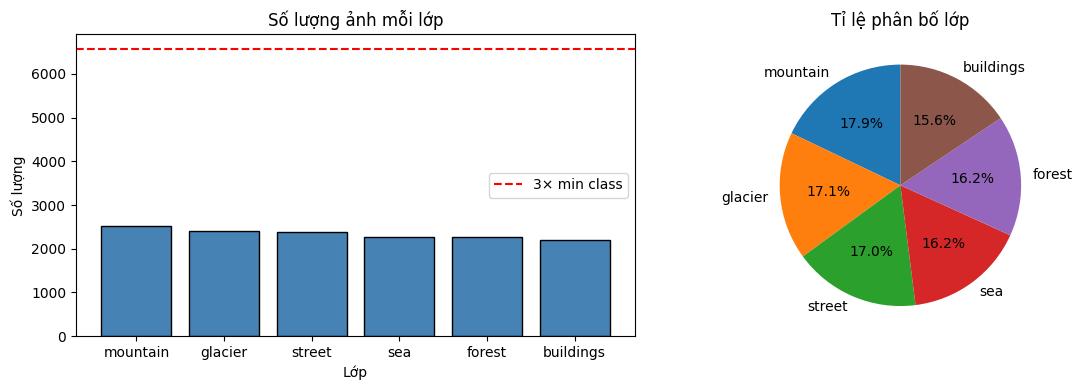

In [10]:
# Đếm số ảnh mỗi lớp
class_counts = df['label'].value_counts().sort_values(ascending=False)
print('Số lượng ảnh mỗi lớp:')
print(class_counts)

# Tính tỉ lệ
class_ratio = class_counts / class_counts.sum()
print('\nTỉ lệ (%) mỗi lớp:')
print((class_ratio * 100).round(2))

# Imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\nImbalance Ratio (max/min): {imbalance_ratio:.2f}')
print(f'Vượt ngưỡng 3×: {imbalance_ratio > 3}')

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
axes[0].axhline(class_counts.min() * 3, color='red', linestyle='--', label='3× min class')
axes[0].set_title('Số lượng ảnh mỗi lớp')
axes[0].set_xlabel('Lớp')
axes[0].set_ylabel('Số lượng')
axes[0].legend()

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỉ lệ phân bố lớp')

plt.tight_layout()
plt.show()

**📝 Phân tích kết quả:**

> TODO: Nhận xét về mức độ cân bằng lớp. Imbalance ratio có vượt ngưỡng 3× không? Cần xử lý không?

---
### 3c. Phát hiện ảnh trùng lặp (Perceptual Hash – pHash)

**Lý thuyết:**

Thuật toán pHash hoạt động thế nào (Từng bước một)?Chuyển về ảnh xám (Grayscale): Loại bỏ thông tin màu sắc, chỉ giữ lại cường độ sáng để tính toán nhanh hơn.Thu nhỏ ảnh (Resize): Nén ảnh về một kích thước siêu nhỏ (thường là $32 \times 32$). Việc này bỏ qua các chi tiết thừa thãi và chỉ giữ lại "khung xương" cấu trúc của ảnh.Biến đổi Cosin rời rạc (Discrete Cosine Transform - DCT): Đây là "trái tim" của pHash. Thuật toán này tách ảnh thành các dải tần số.Tần số thấp: Thể hiện cấu trúc chung, hình khối lớn (mặt người, cái cây).Tần số cao: Thể hiện chi tiết, nhiễu (nếp nhăn, nhiễu hạt).Cắt bỏ tần số cao: pHash chỉ lấy một góc nhỏ ở trên cùng bên trái của ma trận DCT (thường là $8 \times 8$), tức là chỉ giữ lại cấu trúc lõi của bức ảnh.Tính giá trị trung vị (Median): Tính giá trị trung vị của các phần tử trong ma trận $8 \times 8$ vừa lấy.Nhị phân hóa (Binarization): So sánh từng điểm trong ma trận với giá trị trung vị. Lớn hơn thì gán là 1, nhỏ hơn thì gán là 0. Bạn sẽ thu được một chuỗi 64 bit (ví dụ: 10101100...). Đây chính là mã băm pHash.

**Perceptual Hash (pHash)** chuyển ảnh thành một chuỗi hash ngắn dựa trên nội dung hình ảnh (qua DCT). Hai ảnh giống nhau sẽ có hash tương tự, đo bằng **Hamming Distance**:

$$d_H(h_1, h_2) = \sum_{i} \mathbb{1}[h_1^{(i)} \neq h_2^{(i)}]$$

- $d_H = 0$: ảnh giống hệt nhau
- $d_H \leq 10$: ảnh gần trùng (near-duplicate)

── Phase 1: Hashing ──────────────────────────────────────
  Hashing: 14034/14034

── Phase 2: Duplicate search ─────────────────────────────

════════════════════════════════════════════════════
  KẾT QUẢ  (pHash tự implement + sklearn BallTree)
════════════════════════════════════════════════════
  Tổng ảnh hash thành công : 14034
  Hash thất bại            : 0
  Exact duplicate groups   : 38
  Ảnh dư thừa (exact)      : 38  (0.27%)
  Near-duplicate pairs     : 173  (Hamming ≤ 10)


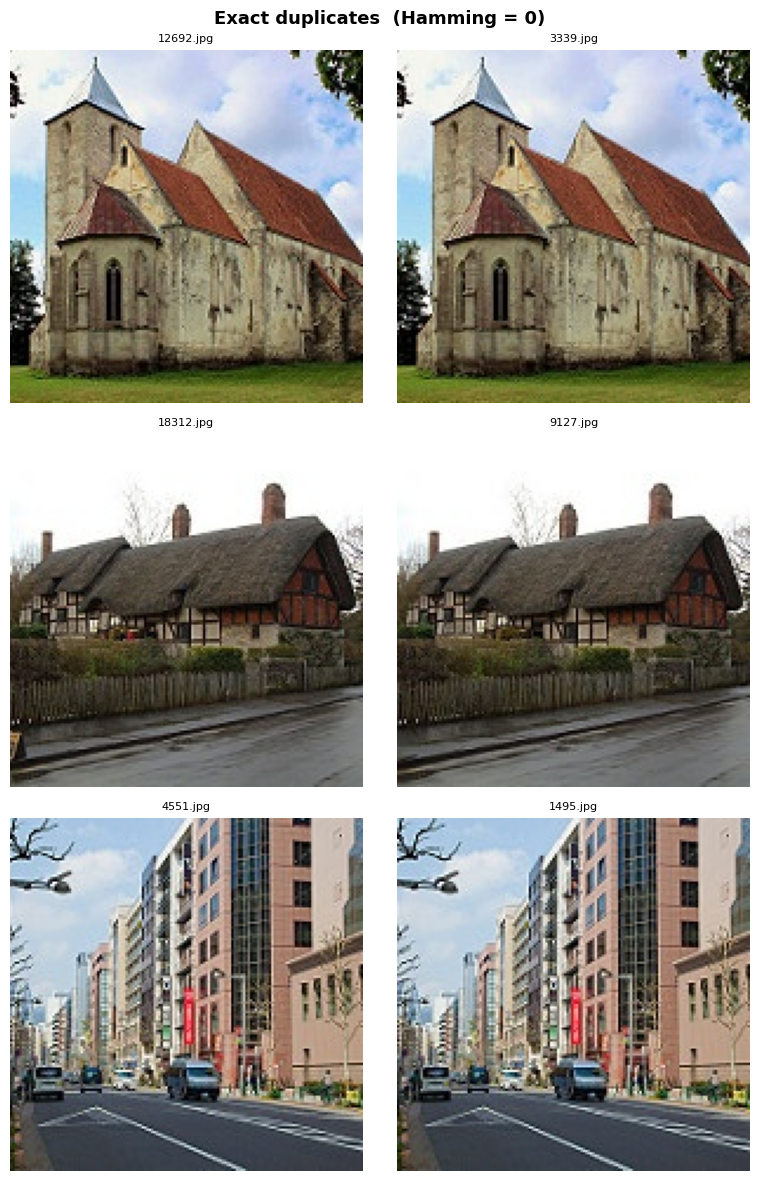

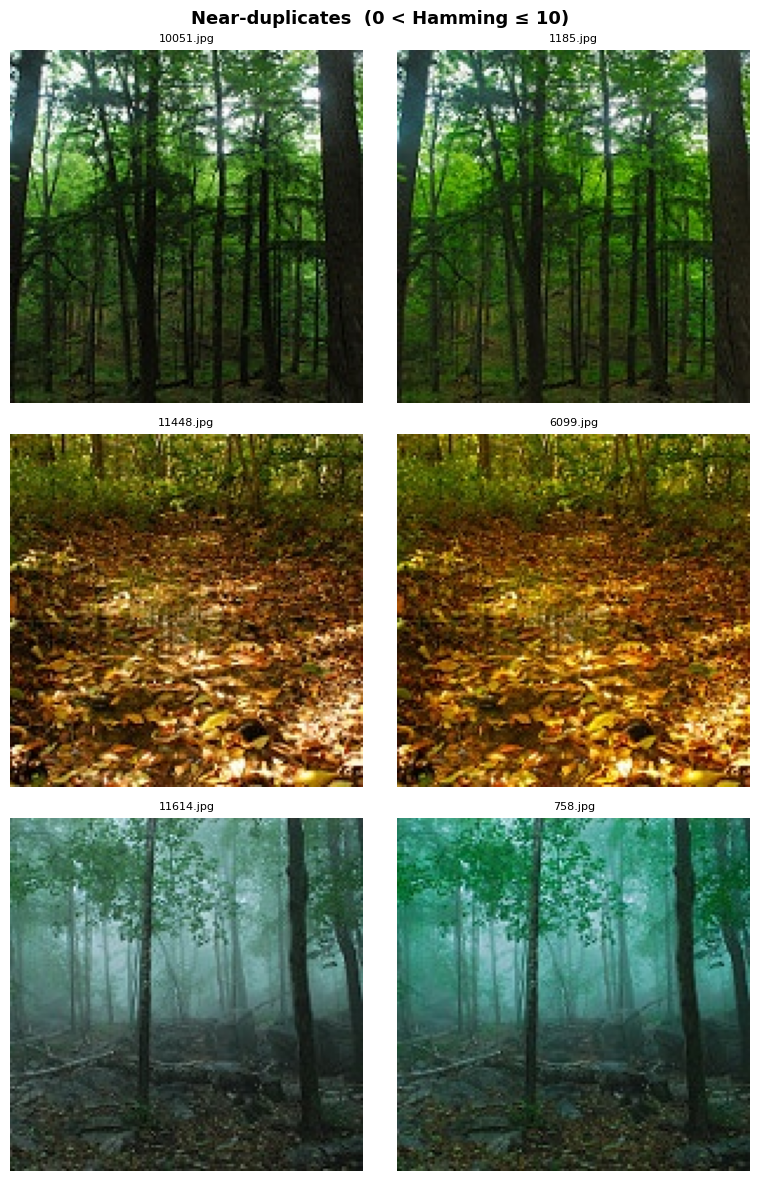


Sau khi loại bỏ: 14034 → 13846 ảnh (đã xóa 188)


In [ ]:

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

PHASH_THRESHOLD = 10   # Hamming distance tối đa (0–64)
HASH_SIZE       = 8    # → hash 64-bit (8×8)

# PHẦN 1 — tự implement pHash bằng numpy + scipy (không cần imagehash)

def compute_phash_vector(path: str, hash_size: int = HASH_SIZE) -> tuple[str, np.ndarray | None]:
    """
    Tính pHash thủ công — trả về bit vector (hash_size²,) uint8.
    Giữ nguyên 6 bước thuật toán: grayscale → resize → DCT → crop → median → binarize.
    """
    try:
        img_size = hash_size * 4                           # 32×32
        with Image.open(path) as img:
            gray    = img.convert('L')
            small   = gray.resize((img_size, img_size), Image.BILINEAR)
            pixels  = np.array(small, dtype=np.float32)

            dct_2d  = scipy.fftpack.dct(                   # DCT theo cả 2 trục
                          scipy.fftpack.dct(pixels, axis=0, norm='ortho'), axis=1, norm='ortho')
            low_freq = dct_2d[:hash_size, :hash_size]      # góc 8×8 tần số thấp

            median  = np.median(low_freq)
            bits    = (low_freq > median).flatten()        # (64,) bool
            return path, bits.astype(np.uint8)
    except Exception as e:
        logging.warning(f"Cannot hash {path}: {e}")
        return path, None
    
# PHẦN 2 — Parallel hashing với ThreadPoolExecutor  (stdlib)

def compute_hashes_parallel(paths: list[str]) -> tuple[np.ndarray, list[str], list[str]]:
    """
    Trả về:
      hash_matrix  — (N_valid, 64) uint8, mỗi hàng là 1 hash vector
      valid_paths  — paths tương ứng với từng hàng
      failed_paths — paths không hash được
    """
    n_workers = multiprocessing.cpu_count()
    results: dict[str, np.ndarray] = {}
    failed: list[str] = []

    with ThreadPoolExecutor (max_workers=n_workers) as executor:
        futures = {executor.submit(compute_phash_vector, p): p for p in paths}
        done = 0
        for future in as_completed(futures):
            path, vec = future.result()
            if vec is not None:
                results[path] = vec
            else:
                failed.append(path)
            done += 1
            if done % 500 == 0 or done == len(paths):
                print(f"  Hashing: {done}/{len(paths)}", end='\r')

    print()
    # Giữ thứ tự theo df để map lại sau
    valid_paths = [p for p in paths if p in results]
    hash_matrix = np.stack([results[p] for p in valid_paths])  # (N, 64)
    return hash_matrix, valid_paths, failed

# PHẦN 3 — Near-duplicate search bằng sklearn NearestNeighbors
#           metric='hamming' + BallTree ≈ BK-tree về hiệu quả

def find_duplicates_sklearn(
    hash_matrix: np.ndarray,
    valid_paths: list[str],
    threshold: int = PHASH_THRESHOLD
) -> tuple[list[tuple], list[tuple]]:
    """
    Dùng NearestNeighbors(metric='hamming', algorithm='ball_tree').

    Lưu ý quan trọng:
      sklearn chuẩn hóa hamming = số bit khác / tổng số bit
      → threshold thực = threshold / hash_size²  (ví dụ: 10/64 ≈ 0.156)
    """
    n_bits       = hash_matrix.shape[1]                   # 64
    radius_norm  = threshold / n_bits                     # chuẩn hóa về [0, 1]

    nn = NearestNeighbors(
        metric='hamming',
        algorithm='ball_tree',     # BallTree partitioning → O(N log N)
        n_jobs=-1                  # dùng tất cả CPU cores
    )
    nn.fit(hash_matrix)

    # radius_neighbors: tìm tất cả điểm trong vòng bán kính
    distances_list, indices_list = nn.radius_neighbors(
        hash_matrix, radius=radius_norm, sort_results=True
    )

    exact_pairs, near_pairs = [], []
    seen = set()

    for i, (dists, idxs) in enumerate(zip(distances_list, indices_list)):
        for dist_norm, j in zip(dists, idxs):
            if j <= i:                                     # tránh duplicate pair (i,j) và (j,i)
                continue
            dist_bits = round(dist_norm * n_bits)          # convert về bit distance
            key = (i, j)
            if key in seen:
                continue
            seen.add(key)

            pair = (valid_paths[i], valid_paths[j], dist_bits)
            (exact_pairs if dist_bits == 0 else near_pairs).append(pair)

    return (
        sorted(exact_pairs, key=lambda x: x[2]),
        sorted(near_pairs,  key=lambda x: x[2])
    )

# PHẦN 4 — Chạy pipeline

print("── Phase 1: Hashing ──────────────────────────────────────")
hash_matrix, valid_paths, failed_paths = compute_hashes_parallel(df['path'].tolist())

if failed_paths:
    print(f"Không hash được: {len(failed_paths)} ảnh")

print("\n── Phase 2: Duplicate search ─────────────────────────────")
exact_pairs, near_dup_pairs = find_duplicates_sklearn(hash_matrix, valid_paths)

# Nhóm exact dups lại theo hash string (để thống kê group)
exact_groups: dict[str, list[str]] = defaultdict(list)
for p1, p2, _ in exact_pairs:
    # Hai ảnh cùng nhóm nếu share cùng hash
    path_to_idx = {p: i for i, p in enumerate(valid_paths)}
    h1 = hash_matrix[path_to_idx[p1]].tobytes()
    exact_groups[h1].extend([p1, p2])
# Deduplicate paths trong cùng group

def build_exact_groups(exact_pairs: list[tuple]) -> dict[str, list[str]]:
    """
    Union-Find: nếu A==B và B==C thì A,B,C cùng 1 nhóm.
    exact_pairs chỉ cho pairs — không tự động transitive.
    """
    parent = {}

    def find(x):
        parent.setdefault(x, x)
        if parent[x] != x:
            parent[x] = find(parent[x])   # path compression
        return parent[x]

    def union(x, y):
        parent[find(x)] = find(y)

    for p1, p2, _ in exact_pairs:
        union(p1, p2)

    groups = defaultdict(list)
    for p in set(p for pair in exact_pairs for p in pair[:2]):
        groups[find(p)].append(p)

    return dict(groups)


exact_groups = build_exact_groups(exact_pairs)
n_exact_images = sum(len(v) - 1 for v in exact_groups.values())

# PHẦN 5 — Report

print(f"\n{'═'*52}")
print(f"  KẾT QUẢ  (pHash tự implement + sklearn BallTree)")
print(f"{'═'*52}")
print(f"  Tổng ảnh hash thành công : {len(valid_paths)}")
print(f"  Hash thất bại            : {len(failed_paths)}")
print(f"  Exact duplicate groups   : {len(exact_groups)}")
print(f"  Ảnh dư thừa (exact)      : {n_exact_images}  "
      f"({n_exact_images / len(df) * 100:.2f}%)")
print(f"  Near-duplicate pairs     : {len(near_dup_pairs)}  "
      f"(Hamming ≤ {PHASH_THRESHOLD})")

# PHẦN 6 — Visualize (matplotlib + PIL)

def show_dup_pairs(pairs: list[tuple], title: str, max_show: int = 3):
    n = min(max_show, len(pairs))
    if n == 0:
        print(f"Không tìm thấy: {title}")
        return

    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    axes = np.array(axes).reshape(-1, 2)                   # đảm bảo 2D kể cả n=1

    for (p1, p2, dist), row in zip(pairs[:n], axes):
        for ax, path in zip(row, [p1, p2]):
            ax.imshow(np.array(Image.open(path)))
            ax.set_title(Path(path).name, fontsize=8)
            ax.axis('off')
        row[0].set_xlabel(f'Hamming distance: {dist} / 64', fontsize=9)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_dup_pairs(exact_pairs,   'Exact duplicates  (Hamming = 0)')
show_dup_pairs(near_dup_pairs, f'Near-duplicates  (0 < Hamming ≤ {PHASH_THRESHOLD})')

# PHẦN 7 — Loại bỏ và cập nhật df

def pick_best(paths: list[str]) -> str:
    return max(paths, key=lambda p: Path(p).stat().st_size)  # giữ file lớn nhất

exact_to_remove = {
    p for paths in exact_groups.values()
    for p in paths if p != pick_best(paths)   # giữ ảnh tốt nhất
}
near_to_remove  = {p2 for _, p2, _ in near_dup_pairs}
all_to_remove   = exact_to_remove | near_to_remove

df_clean = df[~df['path'].isin(all_to_remove)].reset_index(drop=True)

print(f"\nSau khi loại bỏ: {len(df)} → {len(df_clean)} ảnh "
      f"(đã xóa {len(df) - len(df_clean)})")

df = df_clean

**📝 Phân tích kết quả:**

> TODO: Tỉ lệ trùng lặp là bao nhiêu? Đã xử lý như thế nào? Có ảnh hưởng đến chất lượng mô hình không?

---
### 3d. Phân tích độ sáng & độ tương phản theo lớp (Boxplot)

**Lý thuyết:**

- **Mean Intensity** (độ sáng trung bình): $\mu = \frac{1}{HW} \sum_{i,j} I(i,j)$
- **Standard Deviation** (độ tương phản): $\sigma = \sqrt{\frac{1}{HW} \sum_{i,j} (I(i,j) - \mu)^2}$

Boxplot theo lớp cho thấy liệu độ sáng/tương phản có phân biệt được các lớp hay không.

In [ ]:
# TODO: Tính mean intensity và std cho từng ảnh
results = []
for cls in CLASSES:
    for img_arr in images_by_class[cls]:
        gray = cv2.cvtColor(img_arr, cv2.COLOR_RGB2GRAY)
        mean_intensity = float(np.mean(gray))
        std_contrast = float(np.std(gray))
        results.append({'label': cls, 'mean_intensity': mean_intensity, 'std_contrast': std_contrast})

stats_df = pd.DataFrame(results)
print('Thống kê mô tả theo lớp:')
display(stats_df.groupby('label')[['mean_intensity', 'std_contrast']].describe().round(2))

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=stats_df, x='label', y='mean_intensity', ax=axes[0], palette='Set2')
axes[0].set_title('Mean Intensity theo lớp')
axes[0].set_xlabel('Lớp')
axes[0].set_ylabel('Mean Intensity')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=stats_df, x='label', y='std_contrast', ax=axes[1], palette='Set3')
axes[1].set_title('Độ tương phản (Std) theo lớp')
axes[1].set_xlabel('Lớp')
axes[1].set_ylabel('Standard Deviation')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

NameError: name 'images_by_class' is not defined

In [13]:
from scipy import stats

# ── 1. Tính mean intensity + std cho từng ảnh ────────────────────
# Dùng toàn bộ images_by_class (đã sample ở bước trước)
records = [
    {
        'label':          cls,
        'mean_intensity': np.mean(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)),
        'std_contrast':   np.std(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)),
    }
    for cls in CLASSES
    for img in images_by_class[cls]
]
stats_df = pd.DataFrame(records)


# ── 2. Thống kê mô tả ────────────────────────────────────────────
print('Thống kê mô tả theo lớp:')
display(
    stats_df.groupby('label')[['mean_intensity', 'std_contrast']]
            .describe().round(2)
)


# ── 3. ANOVA test — kiểm tra sự khác biệt có ý nghĩa thống kê ───
def run_anova(df: pd.DataFrame, metric: str) -> tuple[float, float, str]:
    """One-way ANOVA: H0 = mean của tất cả classes bằng nhau."""
    groups = [grp[metric].values for _, grp in df.groupby('label')]
    f_stat, p_val = stats.f_oneway(*groups)
    significance = (
        '***' if p_val < 0.001 else
        '**'  if p_val < 0.01  else
        '*'   if p_val < 0.05  else 'ns'
    )
    return f_stat, p_val, significance

f_int, p_int, sig_int = run_anova(stats_df, 'mean_intensity')
f_con, p_con, sig_con = run_anova(stats_df, 'std_contrast')

print(f"\nANOVA – Mean Intensity : F={f_int:.2f}, p={p_int:.4f} {sig_int}")
print(f"ANOVA – Std Contrast   : F={f_con:.2f}, p={p_con:.4f} {sig_con}")


# ── 4. Vẽ boxplot + stripplot + annotate median ──────────────────
PALETTE = 'Set2'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title, ylabel, f_stat, p_val, sig in [
    (axes[0], 'mean_intensity', 'Mean Intensity theo lớp',
     'Mean Intensity (0–255)', f_int, p_int, sig_int),
    (axes[1], 'std_contrast',   'Độ tương phản (Std) theo lớp',
     'Standard Deviation',      f_con, p_con, sig_con),
]:
    # Boxplot nền
    sns.boxplot(
        data=stats_df, x='label', y=metric,
        ax=ax, palette=PALETTE,
        width=0.5, fliersize=0,          # ẩn outlier riêng vì stripplot đã show
        linewidth=1.2,
    )
    # Strip plot — hiển thị từng điểm dữ liệu thực
    sns.stripplot(
        data=stats_df, x='label', y=metric,
        ax=ax, color='black', alpha=0.25,
        size=3, jitter=True,
    )
    # Annotate median value lên từng box
    medians = stats_df.groupby('label')[metric].median()
    for i, cls in enumerate(CLASSES):
        ax.text(
            i, medians[cls],
            f'{medians[cls]:.1f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='#333333'
        )

    # ANOVA result ở góc trên
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Lớp', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.annotate(
        f'ANOVA: F={f_stat:.2f}, p={p_val:.4f} {sig}',
        xy=(0.02, 0.97), xycoords='axes fraction',
        fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.8)
    )

plt.suptitle(
    'Phân tích độ sáng và độ tương phản toàn cục theo lớp',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


# ── 5. Summary insight tự động ───────────────────────────────────
brightest = stats_df.groupby('label')['mean_intensity'].median().idxmax()
darkest   = stats_df.groupby('label')['mean_intensity'].median().idxmin()
most_contrast = stats_df.groupby('label')['std_contrast'].median().idxmax()
least_contrast = stats_df.groupby('label')['std_contrast'].median().idxmin()

print(f"\n📊 Insight tự động:")
print(f"  Sáng nhất   : {brightest}")
print(f"  Tối nhất    : {darkest}")
print(f"  Contrast cao nhất : {most_contrast}")
print(f"  Contrast thấp nhất: {least_contrast}")
if sig_int != 'ns':
    print(f"  → Sự khác biệt mean intensity giữa các lớp có ý nghĩa thống kê (p={p_int:.4f})")
else:
    print(f"  → Không có sự khác biệt đáng kể về mean intensity giữa các lớp")

NameError: name 'images_by_class' is not defined

**📝 Phân tích kết quả:**

> TODO: Lớp nào sáng nhất / tối nhất? Lớp nào có độ tương phản cao nhất? Những đặc trưng này có giúp phân biệt lớp không?

---
<a id='4'></a>
## 4. Phần 2.1.3 – Kỹ thuật tiền xử lý & Ablation Study

**Phương pháp Ablation Study:** Với mỗi kỹ thuật, huấn luyện k-NN (k=5) hoặc Logistic Regression trên tập ảnh flatten, so sánh accuracy trước và sau.

In [ ]:
# === HÀM ABLATION STUDY DÙNG CHUNG ===
def run_classifier(X, y, model='knn', k=5):
    """
    Flatten ảnh và chạy k-NN hoặc Logistic Regression.
    Trả về accuracy trung bình cross-validation 5-fold.
    """
    X_flat = X.reshape(len(X), -1)
    if model == 'knn':
        clf = KNeighborsClassifier(n_neighbors=k)
    else:
        clf = LogisticRegression(max_iter=500, random_state=SEED)
    scores = cross_val_score(clf, X_flat, y, cv=5, scoring='accuracy', n_jobs=-1)
    return scores.mean(), scores.std()

# Chuẩn bị nhãn số
label2id = {cls: i for i, cls in enumerate(CLASSES)}

# TODO: Xây dựng X_base và y_base từ images_by_class (dùng size=64 làm baseline)
X_base, y_base = [], []
for cls in CLASSES:
    for img in images_by_class[cls]:
        X_base.append(img)
        y_base.append(label2id[cls])
X_base = np.array(X_base)
y_base = np.array(y_base)

# Baseline accuracy
baseline_acc, baseline_std = run_classifier(X_base, y_base, model='knn')
print(f'🔷 Baseline k-NN Accuracy (64×64 RGB): {baseline_acc:.4f} ± {baseline_std:.4f}')

# Dict lưu kết quả ablation
ablation_results = {'Baseline (64×64 RGB)': baseline_acc}

---
### 4a. Resize + Đo lường SSIM / PSNR

**Lý thuyết:**

**SSIM (Structural Similarity Index)** đo mức độ tương đồng về cấu trúc giữa ảnh gốc và ảnh sau resize:
$$\text{SSIM}(x, y) = \frac{(2\mu_x \mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

**PSNR (Peak Signal-to-Noise Ratio)** đo tỉ lệ tín hiệu / nhiễu theo đơn vị dB:
$$\text{PSNR} = 10 \cdot \log_{10}\left(\frac{\text{MAX}^2}{\text{MSE}}\right)$$

- SSIM gần 1 → mất ít thông tin; PSNR cao → chất lượng tốt hơn.

In [ ]:
# TODO: Resize về 3 kích thước và tính SSIM / PSNR
SIZES = [32, 64, 128]
ORIGINAL_SIZE = 150  # kích thước gốc Intel dataset

ssim_scores = {s: [] for s in SIZES}
psnr_scores = {s: [] for s in SIZES}

# Lấy sample ảnh gốc (không resize)
sample_paths = df.sample(100, random_state=SEED)['path'].tolist()

for path in sample_paths:
    orig = load_image_rgb(path, size=ORIGINAL_SIZE)
    for s in SIZES:
        resized = cv2.resize(orig, (s, s))
        resized_back = cv2.resize(resized, (ORIGINAL_SIZE, ORIGINAL_SIZE))
        # SSIM cần cùng kích thước với ảnh gốc
        s_val = ssim(orig, resized_back, channel_axis=2, data_range=255)
        p_val = psnr(orig, resized_back, data_range=255)
        ssim_scores[s].append(s_val)
        psnr_scores[s].append(p_val)

# In kết quả
print('Kết quả SSIM và PSNR theo kích thước:')
print(f'{"Size":>8} | {"SSIM Mean":>12} | {"SSIM Std":>10} | {"PSNR Mean":>12} | {"PSNR Std":>10}')
print('-' * 60)
for s in SIZES:
    sm, ss = np.mean(ssim_scores[s]), np.std(ssim_scores[s])
    pm, ps = np.mean(psnr_scores[s]), np.std(psnr_scores[s])
    print(f'{s:>8} | {sm:>12.4f} | {ss:>10.4f} | {pm:>12.2f} | {ps:>10.2f}')

# Đường cong SSIM theo kích thước
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mean_ssim = [np.mean(ssim_scores[s]) for s in SIZES]
mean_psnr = [np.mean(psnr_scores[s]) for s in SIZES]

axes[0].plot(SIZES, mean_ssim, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Đường cong SSIM theo kích thước')
axes[0].set_xlabel('Kích thước ảnh (px)')
axes[0].set_ylabel('SSIM')
axes[0].set_xticks(SIZES)
axes[0].grid(True)

axes[1].plot(SIZES, mean_psnr, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Đường cong PSNR theo kích thước')
axes[1].set_xlabel('Kích thước ảnh (px)')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_xticks(SIZES)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Ablation: accuracy theo kích thước
for s in SIZES:
    X_s, y_s = [], []
    for cls in CLASSES:
        for img in images_by_class[cls]:
            X_s.append(cv2.resize(img, (s, s)))
            y_s.append(label2id[cls])
    acc, std = run_classifier(np.array(X_s), np.array(y_s))
    ablation_results[f'Resize {s}×{s}'] = acc
    print(f'k-NN Accuracy (size={s}): {acc:.4f} ± {std:.4f}')

**📝 Phân tích kết quả:**

> TODO: Kích thước nào cho SSIM/PSNR cao nhất? Kích thước nào cân bằng tốt giữa chất lượng và tốc độ? Biện hộ cho kích thước được chọn trong các bước tiếp theo.

---
### 4b. Chuyển đổi không gian màu + PCA Explained Variance

**Lý thuyết:**

Các không gian màu khác nhau mã hóa thông tin theo cách khác nhau:
- **RGB**: Red, Green, Blue – không gian màu chuẩn, dễ xử lý
- **Grayscale**: Chỉ có 1 kênh cường độ sáng, loại bỏ thông tin màu
- **HSV**: Hue, Saturation, Value – tách biệt màu sắc và độ sáng, gần với nhận thức của con người
- **LAB**: Lightness, A (green-red), B (blue-yellow) – không gian màu tuyến tính theo cảm nhận thị giác

**PCA Explained Variance** đo lượng thông tin được giữ lại trong $k$ thành phần đầu tiên:
$$\text{EVR}_k = \frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^n \lambda_i}$$

In [ ]:
# TODO: Chuyển đổi không gian màu và tính PCA explained variance
CHOSEN_SIZE = 64  # Kích thước đã chọn ở 4a
N_PCA = 50

color_spaces = {
    'RGB': lambda img: img,
    'Grayscale': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)[..., np.newaxis],
    'HSV': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2HSV),
    'LAB': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
}

pca_variance_results = {}
colorspace_acc = {}

for cs_name, cs_fn in color_spaces.items():
    X_cs, y_cs = [], []
    for cls in CLASSES:
        for img in images_by_class[cls]:
            img_r = cv2.resize(img, (CHOSEN_SIZE, CHOSEN_SIZE))
            img_cs = cs_fn(img_r)
            X_cs.append(img_cs.flatten())
            y_cs.append(label2id[cls])
    X_cs = np.array(X_cs, dtype=np.float32) / 255.0
    y_cs = np.array(y_cs)
    
    # PCA explained variance
    n_components = min(N_PCA, X_cs.shape[1], len(X_cs))
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(X_cs)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    pca_variance_results[cs_name] = cumvar
    
    # Accuracy
    acc, std = run_classifier(X_cs.reshape(len(X_cs), -1), y_cs, model='knn')
    colorspace_acc[cs_name] = acc
    print(f'{cs_name:12s} | PCA-50 EVR: {cumvar[-1]:.4f} | k-NN Acc: {acc:.4f}')
    ablation_results[f'ColorSpace {cs_name}'] = acc

# Vẽ PCA explained variance
plt.figure(figsize=(9, 5))
for cs_name, cumvar in pca_variance_results.items():
    plt.plot(range(1, len(cumvar)+1), cumvar, label=cs_name, linewidth=2)
plt.axhline(0.9, color='gray', linestyle='--', alpha=0.7, label='90%')
plt.title('Cumulative Explained Variance (PCA-50) theo không gian màu')
plt.xlabel('Số thành phần PCA')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**📝 Phân tích kết quả:**

> TODO: Không gian màu nào bảo toàn thông tin tốt nhất (EVR cao nhất)? Không gian màu nào cho accuracy k-NN tốt nhất? Chọn không gian màu nào cho các bước tiếp theo và tại sao?

---
### 4c. Chuẩn hóa + Kiểm định Kolmogorov-Smirnov (KS Test)

**Lý thuyết:**

**4 phương pháp chuẩn hóa:**
1. **Min-Max [0,1]**: $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$
2. **Min-Max [-1,1]**: $x' = 2 \cdot \frac{x - x_{\min}}{x_{\max} - x_{\min}} - 1$
3. **Z-score toàn tập**: $x' = \frac{x - \mu_{\text{all}}}{\sigma_{\text{all}}}$
4. **Z-score per-channel**: $x'_c = \frac{x_c - \mu_c}{\sigma_c}$ cho mỗi kênh $c$

**Kiểm định KS (Kolmogorov-Smirnov):** So sánh phân phối trước và sau chuẩn hóa:
$$D = \sup_x |F_1(x) - F_2(x)|$$
- $p\text{-value} < 0.05$: phân phối thay đổi có ý nghĩa thống kê

In [ ]:
# TODO: Lấy dữ liệu pixel gốc
X_raw = X_base.astype(np.float32)  # shape: (N, 64, 64, 3)
pixels_raw = X_raw.flatten()

# 4 phương pháp chuẩn hóa
def minmax_01(X):
    return X / 255.0

def minmax_11(X):
    return X / 127.5 - 1.0

def zscore_global(X):
    return (X - X.mean()) / (X.std() + 1e-8)

def zscore_perchannel(X):
    X_norm = np.zeros_like(X)
    for c in range(3):
        mu, sigma = X[..., c].mean(), X[..., c].std() + 1e-8
        X_norm[..., c] = (X[..., c] - mu) / sigma
    return X_norm

normalizations = {
    'Min-Max [0,1]': minmax_01,
    'Min-Max [-1,1]': minmax_11,
    'Z-score Global': zscore_global,
    'Z-score Per-channel': zscore_perchannel
}

print(f'{'Phương pháp':25s} | KS Statistic | p-value     | k-NN Acc')
print('-' * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (name, norm_fn) in enumerate(normalizations.items()):
    X_norm = norm_fn(X_raw.copy())
    pixels_norm = X_norm.flatten()
    
    # KS test
    sample_raw = np.random.choice(pixels_raw, 5000, replace=False)
    sample_norm = np.random.choice(pixels_norm, 5000, replace=False)
    ks_stat, p_value = ks_2samp(sample_raw, sample_norm)
    
    # Accuracy
    acc, _ = run_classifier(X_norm, y_base)
    ablation_results[f'Norm {name}'] = acc
    
    print(f'{name:25s} | {ks_stat:12.4f} | {p_value:11.4e} | {acc:.4f}')
    
    # Histogram so sánh
    axes[idx].hist(sample_raw, bins=50, alpha=0.5, label='Gốc', density=True, color='blue')
    axes[idx].hist(sample_norm, bins=50, alpha=0.5, label=name, density=True, color='orange')
    axes[idx].set_title(f'{name}\nKS={ks_stat:.4f}, p={p_value:.2e}')
    axes[idx].legend()
    axes[idx].set_xlabel('Pixel value')

plt.suptitle('So sánh phân phối pixel trước và sau chuẩn hóa', fontsize=13)
plt.tight_layout()
plt.show()

**📝 Phân tích kết quả:**

> TODO: Phương pháp nào thay đổi phân phối nhiều nhất (KS stat cao)? p-value < 0.05 có ý nghĩa gì? Phương pháp chuẩn hóa nào cho accuracy tốt nhất? Phương pháp nào sẽ được chọn và tại sao?

---
### 4d. Data Augmentation + t-SNE Visualization

**Lý thuyết:**

**Data Augmentation** tạo thêm mẫu bằng cách biến đổi hình ảnh gốc, giúp tăng tính đa dạng và giảm overfitting. Các phép biến đổi bao gồm:
- Lật ngang/dọc (flip)
- Xoay ảnh (rotation)
- Cắt ngẫu nhiên (random crop)
- Thêm nhiễu Gaussian
- Điều chỉnh độ sáng/tương phản

**t-SNE** (t-distributed Stochastic Neighbor Embedding) chiếu dữ liệu nhiều chiều xuống 2D để trực quan hóa cấu trúc phân cụm:
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

In [ ]:
# TODO: Pipeline augmentation với 5 phép biến đổi
def augment_image(img):
    """Áp dụng ngẫu nhiên các phép augment lên ảnh numpy (H, W, 3) uint8."""
    # 1. Lật ngang
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
    # 2. Lật dọc
    if random.random() > 0.5:
        img = cv2.flip(img, 0)
    # 3. Xoay (-30 đến +30 độ)
    angle = random.uniform(-30, 30)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h))
    # 4. Thêm nhiễu Gaussian
    if random.random() > 0.5:
        noise = np.random.normal(0, 15, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    # 5. Điều chỉnh độ sáng
    beta = random.uniform(-40, 40)
    img = np.clip(img.astype(np.float32) + beta, 0, 255).astype(np.uint8)
    return img

# Tạo tập augmented
X_aug, y_aug = [], []
for cls in CLASSES:
    for img in images_by_class[cls]:
        aug = augment_image(img.copy())
        X_aug.append(aug)
        y_aug.append(label2id[cls])
X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

# Hiển thị ví dụ augmentation
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, cls in enumerate(CLASSES):
    orig = images_by_class[cls][0]
    aug = augment_image(orig.copy())
    axes[0][i].imshow(orig); axes[0][i].set_title(f'Gốc\n{cls}'); axes[0][i].axis('off')
    axes[1][i].imshow(aug);  axes[1][i].set_title('Augmented'); axes[1][i].axis('off')
plt.suptitle('So sánh ảnh gốc và ảnh sau augmentation', fontsize=13)
plt.tight_layout()
plt.show()

# Accuracy sau augmentation
acc_aug, std_aug = run_classifier(X_aug, y_aug)
ablation_results['Data Augmentation'] = acc_aug
print(f'k-NN Accuracy sau Augmentation: {acc_aug:.4f} ± {std_aug:.4f}')

In [ ]:
# t-SNE: So sánh phân phối đặc trưng trước và sau augmentation
# Dùng PCA trước để giảm chiều, sau đó t-SNE
N_TSNE = 300  # Lấy mẫu để t-SNE nhanh hơn

def run_tsne(X, y, n_samples=N_TSNE, pca_dim=50):
    idx = np.random.choice(len(X), min(n_samples, len(X)), replace=False)
    X_s = X[idx].reshape(len(idx), -1).astype(np.float32) / 255.0
    y_s = y[idx]
    pca = PCA(n_components=min(pca_dim, X_s.shape[1]), random_state=SEED)
    X_pca = pca.fit_transform(X_s)
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    X_2d = tsne.fit_transform(X_pca)
    return X_2d, y_s

X_tsne_orig, y_tsne_orig = run_tsne(X_base, y_base)
X_tsne_aug, y_tsne_aug = run_tsne(X_aug, y_aug)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = sns.color_palette('tab10', n_colors=len(CLASSES))

for ax, X_2d, y_s, title in [
    (axes[0], X_tsne_orig, y_tsne_orig, 'Tập gốc'),
    (axes[1], X_tsne_aug, y_tsne_aug, 'Sau Augmentation')
]:
    for i, cls in enumerate(CLASSES):
        mask = y_s == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[palette[i]], label=cls, alpha=0.6, s=20)
    ax.set_title(f't-SNE – {title}')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

**📝 Phân tích kết quả:**

> TODO: t-SNE cho thấy augmentation làm tập dữ liệu phân tán hơn hay tập trung hơn? Các cụm lớp có tách biệt tốt hơn không? Augmentation có cải thiện accuracy không?

---
### 4e. [Nâng cao] PCA – Scree Plot & 2D/3D Visualization

**Lý thuyết:**

**PCA (Principal Component Analysis)** tìm các hướng có phương sai lớn nhất trong dữ liệu.

**Scree plot** vẽ phương sai giải thích theo từng thành phần, giúp xác định "elbow point" – số thành phần tối ưu.

$$\text{Số PC để giải thích } p\% = \min k \text{ sao cho } \sum_{i=1}^k \lambda_i / \sum \lambda_i \geq p/100$$

In [ ]:
# TODO: PCA trên toàn tập
X_flat = X_base.reshape(len(X_base), -1).astype(np.float32) / 255.0

n_components_full = min(200, X_flat.shape[1], len(X_flat))
pca_full = PCA(n_components=n_components_full, random_state=SEED)
pca_full.fit(X_flat)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Tìm số PC cho 90%, 95%, 99%
for threshold in [0.90, 0.95, 0.99]:
    n_pc = np.argmax(cumvar >= threshold) + 1
    print(f'Số PC để giải thích {threshold*100:.0f}% phương sai: {n_pc}')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color='steelblue')
axes[0].set_title('Scree Plot (30 thành phần đầu)')
axes[0].set_xlabel('Thành phần PCA')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
for th, col in [(0.90, 'green'), (0.95, 'orange'), (0.99, 'red')]:
    axes[1].axhline(th, color=col, linestyle='--', label=f'{th*100:.0f}%')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Số thành phần PCA')
axes[1].set_ylabel('Cumulative EVR')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# PCA 2D visualization
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2d = pca_2d.fit_transform(X_flat)

plt.figure(figsize=(8, 6))
for i, cls in enumerate(CLASSES):
    mask = y_base == i
    plt.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], label=cls, alpha=0.5, s=15)
plt.title('PCA 2D – Phân bố theo lớp')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**📝 Phân tích kết quả:**

> TODO: Cần bao nhiêu PC để đạt 90/95/99%? Elbow point xuất hiện tại vị trí nào trong scree plot? Trong không gian PCA 2D, các lớp có tách biệt nhau không? Lớp nào dễ nhầm lẫn nhất?

---
### 4f. [Nâng cao] Phát hiện cạnh + ANOVA một chiều

**Lý thuyết:**

**Bộ lọc cạnh:**
- **Sobel**: Tính đạo hàm theo hướng x và y, $G = \sqrt{G_x^2 + G_y^2}$
- **Prewitt**: Tương tự Sobel nhưng kernel không trọng số
- **Canny**: Phát hiện cạnh đa tầng (Gaussian blur → gradient → non-max suppression → hysteresis)

**Edge Density**: $\text{ED} = \frac{\text{Số pixel cạnh}}{H \times W}$

**ANOVA một chiều** kiểm định xem trung bình Edge Density có khác nhau giữa các lớp:
$$F = \frac{\text{Between-group variance}}{\text{Within-group variance}}$$
- $p\text{-value} < 0.05$: Có sự khác biệt có ý nghĩa thống kê giữa các lớp

In [ ]:
# TODO: Tính Edge Density theo lớp với nhiều bộ lọc
edge_results = []

for cls in CLASSES:
    for img in images_by_class[cls]:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # Sobel – 2 bộ siêu tham số
        sob1 = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)
        sob2 = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=5)
        ed_sob1 = np.mean(np.abs(sob1) > 30)
        ed_sob2 = np.mean(np.abs(sob2) > 30)
        
        # Prewitt – 2 bộ siêu tham số (dùng kernel thủ công)
        kx = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
        ky = kx.T
        pre_x = cv2.filter2D(gray.astype(np.float32), -1, kx)
        pre_y = cv2.filter2D(gray.astype(np.float32), -1, ky)
        prewitt_mag = np.sqrt(pre_x**2 + pre_y**2)
        ed_pre1 = np.mean(prewitt_mag > 20)
        ed_pre2 = np.mean(prewitt_mag > 40)
        
        # Canny – 2 bộ siêu tham số
        can1 = cv2.Canny(gray, 50, 150)
        can2 = cv2.Canny(gray, 100, 200)
        ed_can1 = np.mean(can1 > 0)
        ed_can2 = np.mean(can2 > 0)
        
        edge_results.append({
            'label': cls,
            'Sobel(k=3)': ed_sob1, 'Sobel(k=5)': ed_sob2,
            'Prewitt(t=20)': ed_pre1, 'Prewitt(t=40)': ed_pre2,
            'Canny(50,150)': ed_can1, 'Canny(100,200)': ed_can2
        })

edge_df = pd.DataFrame(edge_results)

# ANOVA cho từng bộ lọc
edge_methods = ['Sobel(k=3)', 'Sobel(k=5)', 'Prewitt(t=20)', 'Prewitt(t=40)', 'Canny(50,150)', 'Canny(100,200)']
print(f'{'Bộ lọc':20s} | F-statistic | p-value     | Kết luận')
print('-' * 70)
for method in edge_methods:
    groups = [edge_df[edge_df['label'] == cls][method].values for cls in CLASSES]
    F, p = f_oneway(*groups)
    conclusion = 'Khác biệt' if p < 0.05 else '❌ Không khác biệt'
    print(f'{method:20s} | {F:11.4f} | {p:11.4e} | {conclusion}')

# Boxplot Edge Density
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, method in enumerate(edge_methods):
    sns.boxplot(data=edge_df, x='label', y=method, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Edge Density – {method}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Edge Density theo lớp (6 bộ lọc)', fontsize=13)
plt.tight_layout()
plt.show()

**📝 Phân tích kết quả:**

> TODO: ANOVA cho p-value < 0.05 với bộ lọc nào? Điều này có nghĩa là gì? Lớp nào có Edge Density cao nhất/thấp nhất? Thông tin cạnh có đủ để phân biệt các lớp không?

---
<a id='5'></a>
## 5. Tổng hợp kết quả Ablation Study

In [ ]:
# Tổng hợp tất cả kết quả ablation
ablation_df = pd.DataFrame(list(ablation_results.items()), columns=['Kỹ thuật', 'k-NN Accuracy'])
ablation_df = ablation_df.sort_values('k-NN Accuracy', ascending=False).reset_index(drop=True)

print('=== BẢNG TỔNG HỢP ABLATION STUDY ===')
display(ablation_df.style.highlight_max(subset=['k-NN Accuracy'], color='lightgreen')
                         .highlight_min(subset=['k-NN Accuracy'], color='lightcoral')
                         .format({'k-NN Accuracy': '{:.4f}'}))

# Biểu đồ so sánh
plt.figure(figsize=(12, 6))
colors_bar = ['gold' if x == ablation_df['k-NN Accuracy'].max() else 
              'salmon' if x == ablation_df['k-NN Accuracy'].min() else 'steelblue' 
              for x in ablation_df['k-NN Accuracy']]
bars = plt.barh(ablation_df['Kỹ thuật'], ablation_df['k-NN Accuracy'], color=colors_bar, edgecolor='black')
plt.axvline(ablation_results['Baseline (64×64 RGB)'], color='red', linestyle='--', label='Baseline')
plt.xlabel('k-NN Accuracy (5-fold CV)')
plt.title('Ablation Study – So sánh tác động của các kỹ thuật tiền xử lý')
plt.legend()
plt.tight_layout()
plt.show()

## 📌 Kết luận & Pipeline tiền xử lý được chọn

**Dựa trên kết quả Ablation Study, pipeline tiền xử lý tối ưu gồm:**

| Bước | Kỹ thuật | Lý do chọn |
|------|----------|------------|
| 1 | Resize `??×??` | SSIM/PSNR tốt nhất, cân bằng chất lượng/tốc độ |
| 2 | Không gian màu `??` | EVR cao nhất, accuracy tốt nhất |
| 3 | Chuẩn hóa `??` | Phân phối sau KS test phù hợp nhất |
| 4 | Data Augmentation | Tăng đa dạng, cải thiện generalization |

> **TODO**: Điền vào bảng và viết đoạn nhận xét tổng quan. Kỹ thuật nào cải thiện nhiều nhất so với baseline? Kỹ thuật nào ít tác động?